# 2. Wstępne Przetwarzanie Danych i Ekstrakcja Cech

---

## Zadania

1. **Scalenie zbiorów** - połączenie RAVDESS i CREMA-D do wspólnego zbioru 6 emocji
2. **Czyszczenie i normalizacja** - ujednolicenie SR, konwersja do mono, trimming, peak-normalizacja
3. **Podział na zbiory** - podział na train/val/test
4. **Ekstrakcja cech** - zestaw parametrów dla klasycznego ML, mel-spektrogramy (dla CNN), wav dla modelu transformer
5. **Augmentacja** - stosowana wyłącznie na zbiorze treningowym
6. **Zapis** - wynikowych tablic do `data/processed/`

## 1. Importy i konfiguracja

In [2]:
import os
import warnings
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

NOTEBOOK_DIR = Path(os.getcwd())
ROOT_DIR = NOTEBOOK_DIR.parent
RAVDESS_DIR = ROOT_DIR / 'data' / 'ravdess'
CREMAD_DIR = ROOT_DIR / 'data' / 'cremad'
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
RESULTS_DIR = ROOT_DIR / 'results' / '02_preprocessing'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Katalog danych RAVDESS: {RAVDESS_DIR}')
print(f'Katalog danych CREMA-D: {CREMAD_DIR}')
print(f'Katalog danych przetworzonych: {PROCESSED_DIR}')

Katalog danych RAVDESS: d:\zum\data\ravdess
Katalog danych CREMA-D: d:\zum\data\cremad
Katalog danych przetworzonych: d:\zum\data\processed


### 1.1 Definicja docelowych parametrów zbiorów

| Problem | Decyzja | Uzasadnienie |
|---------|---------|-------------- |
| RAVDESS 48 kHz, CREMA-D 16 kHz | Resample do **16 000 Hz** | Ujednolicenie, 16kHz wymagane przez HuBERT, dobry kompromis jakość/koszt |
| RAVDESS stereo (~8% plików) | Konwersja do **mono** | Ujednolicenie |
| Klasy *calm* i *surprised* tylko w RAVDESS | **Usunięcie** tych klas | Brak odpowiedników w CREMA-D - nierównowaga przy uczeniu |
| Różne długości (RAVDESS ~3.7s, CREMA-D ~2.5s) | **Padding/truncation do 3 s** | Stała długość wymagana przez modele |
| Nauka aktora nie wzorca | Podział **na poziomie aktorów** | Ten sam aktor nie może być w train i test |

In [3]:
# Parametry audio
TARGET_SR  = 16_000          # docelowa częstotliwość próbkowania [Hz]
DURATION = 3.0               # docelowa długość nagrania [s]
N_SAMPLES = int(TARGET_SR * DURATION)

# Parametry cech
N_MFCC = 40         # liczba współczynników MFCC
N_MELS = 128        # liczba pasm melowych
N_FFT = 2048        # rozmiar okna FFT
HOP_LENGTH = 512    # przeskok okna

# Parametry augmentacji
NOISE_FACTOR = 0.005         # współczynnik szumu
STRETCH_RATES = [0.90, 1.10] # współczynniki zmiany rozciągnięcia w czasie
PITCH_STEPS = [-2, 2]        # zmiana tonów (półtony)

# Deterministyczne ziarno dla reprodukowalności
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Wspólne emocje
EMOTIONS_LIST = ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']

## 2. Scalenie zbiorów

### 2.1 RAVDESS - parsowanie metadanych z nazw plików

In [4]:
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}
RAVDESS_INTENSITY_MAP = {'01': 'normal', '02': 'strong'}
RAVDESS_STATEMENT_MAP = {'01': 'Kids are talking by the door',
                         '02': 'Dogs are sitting by the door'}
RAVDESS_GENDER_MAP = lambda a: 'male' if int(a) % 2 == 1 else 'female'

def parse_ravdess(filepath):
    fname = os.path.basename(filepath)
    parts = fname.replace('.wav', '').split('-')
    if len(parts) != 7:
        return None
    modality, vocal_ch, emotion, intensity, statement, repetition, actor = parts
    return {
        'filepath': str(filepath),
        'filename': fname,
        'modality': modality,
        'vocal_channel': vocal_ch,
        'emotion_code': emotion,
        'emotion': RAVDESS_EMOTION_MAP.get(emotion, 'unknown'),
        'intensity': RAVDESS_INTENSITY_MAP.get(intensity, intensity),
        'statement': RAVDESS_STATEMENT_MAP.get(statement, statement),
        'repetition': int(repetition),
        'actor': int(actor),
        'gender': RAVDESS_GENDER_MAP(actor),
        'dataset': 'RAVDESS'
    }

ravdess_records = [parse_ravdess(p) for p in sorted(RAVDESS_DIR.glob('*.wav'))]
ravdess_df = pd.DataFrame(ravdess_records)
print(f'Liczba wczytanych plików: {len(ravdess_df)}')
ravdess_df.head(5)

Liczba wczytanych plików: 1440


,filepath,filename,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor,gender,dataset
0,d:\zum\data\ravdess\03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,03,01,01,neutral,normal,Kids are talking by the door,1,1,male,RAVDESS
1,d:\zum\data\ravdess\03-01-01-01-01-01-02.wav,03-01-01-01-01-01-02.wav,03,01,01,neutral,normal,Kids are talking by the door,1,2,female,RAVDESS
2,d:\zum\data\ravdess\03-01-01-01-01-01-03.wav,03-01-01-01-01-01-03.wav,03,01,01,neutral,normal,Kids are talking by the door,1,3,male,RAVDESS
3,d:\zum\data\ravdess\03-01-01-01-01-01-04.wav,03-01-01-01-01-01-04.wav,03,01,01,neutral,normal,Kids are talking by the door,1,4,female,RAVDESS
4,d:\zum\data\ravdess\03-01-01-01-01-01-05.wav,03-01-01-01-01-01-05.wav,03,01,01,neutral,normal,Kids are talking by the door,1,5,male,RAVDESS


### 2.2 CREMA-D - parsowanie metadanych z nazw plików

In [5]:
CREMAD_EMOTION_MAP = {
    'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
    'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'
}
CREMAD_LEVEL_MAP = {'LO': 'low', 'MD': 'medium', 'HI': 'high', 'XX': 'unspecified'}
CREMAD_SENTENCES = {
    'IEO': "It's eleven o'clock", 'TIE': 'That is exactly what happened',
    'IOM': "I'm on my way to the meeting", 'IWW': 'I wonder what this is about',
    'TAI': 'The airplane is almost full', 'MTI': 'Maybe tomorrow it will be cold',
    'IWL': 'I would like a new alarm clock', 'ITH': "I think I have a doctor's appointment",
    'DFA': "Don't forget a jacket", 'ITS': "I think I've seen this before",
    'TSI': 'The surface is slick', 'WSI': "We'll stop in a couple of minutes"
}

def parse_cremad(filepath):
    fname = os.path.basename(str(filepath))
    parts = fname.replace('.wav', '').split('_')
    if len(parts) != 4:
        return None
    actor_id, sentence, emotion, level = parts
    try:
        actor_num = int(actor_id)
    except:
        return None
    return {
        'filepath': str(filepath),
        'filename': fname,
        'actor': actor_num,
        'sentence': CREMAD_SENTENCES.get(sentence, sentence),
        'sentence_code': sentence,
        'emotion_code': emotion,
        'emotion': CREMAD_EMOTION_MAP.get(emotion, 'unknown'),
        'level': CREMAD_LEVEL_MAP.get(level, level),
        'level_code': level,
        'dataset': 'CREMA-D'
    }

cremad_records = [parse_cremad(p) for p in sorted(CREMAD_DIR.glob('*.wav'))]
cremad_df = pd.DataFrame(cremad_records)
print(f'Liczba plików CREMA-D: {len(cremad_df)}')
cremad_df.head(5)

Liczba plików CREMA-D: 7442


,filepath,filename,actor,sentence,sentence_code,emotion_code,emotion,level,level_code,dataset
0,d:\zum\data\cremad\1001_DFA_ANG_XX.wav,1001_DFA_ANG_XX.wav,1001,Don't forget a jacket,DFA,ANG,angry,unspecified,XX,CREMA-D
1,d:\zum\data\cremad\1001_DFA_DIS_XX.wav,1001_DFA_DIS_XX.wav,1001,Don't forget a jacket,DFA,DIS,disgust,unspecified,XX,CREMA-D
2,d:\zum\data\cremad\1001_DFA_FEA_XX.wav,1001_DFA_FEA_XX.wav,1001,Don't forget a jacket,DFA,FEA,fearful,unspecified,XX,CREMA-D
3,d:\zum\data\cremad\1001_DFA_HAP_XX.wav,1001_DFA_HAP_XX.wav,1001,Don't forget a jacket,DFA,HAP,happy,unspecified,XX,CREMA-D
4,d:\zum\data\cremad\1001_DFA_NEU_XX.wav,1001_DFA_NEU_XX.wav,1001,Don't forget a jacket,DFA,NEU,neutral,unspecified,XX,CREMA-D


### 2.3 Scalenie i filtrowanie do 6 wspólnych emocji

RAVDESS zawiera **8 emocji**, CREMA-D zawiera **6 emocji**. Wspólne klasy to:  
angry, disgust, fearful, happy, neutral, sad

Klasy *calm* i *surprised* (tylko RAVDESS) zostają usunięte, ponieważ po scaleniu zbiorów mają niewystarczającą reprezentację.

Używamy LabelEncoder aby zamienić etykiety emocji słowne na liczbowe.

In [6]:
# Filtrowanie wspólnych emocji
ravdess_filtered = ravdess_df[ravdess_df['emotion'].isin(EMOTIONS_LIST)].copy()
cremad_filtered  = cremad_df[cremad_df['emotion'].isin(EMOTIONS_LIST)].copy()

print(f'Usunięte z RAVDESS: calm={( ravdess_df["emotion"]=="calm").sum()}, '
      f'surprised={(ravdess_df["emotion"]=="surprised").sum()} próbek')

# Wspólny zbiór dla 6-ciu emocji
common_df = pd.concat([ravdess_filtered, cremad_filtered], ignore_index=True)

# Etykietowanie
label_encoder = LabelEncoder()
label_encoder.fit(sorted(EMOTIONS_LIST))
common_df['label'] = label_encoder.transform(common_df['emotion'])

print(f'\nZbiór scalony: {len(common_df)} nagrań')
print(f'  RAVDESS: {(common_df["dataset"]=="RAVDESS").sum()}')
print(f'  CREMA-D: {(common_df["dataset"]=="CREMA-D").sum()}')
print(f'\nRozkład emocji:')
print(common_df['emotion'].value_counts())

Usunięte z RAVDESS: calm=192, surprised=192 próbek

Zbiór scalony: 8498 nagrań
  RAVDESS: 1056
  CREMA-D: 7442

Rozkład emocji:
emotion
happy      1463
sad        1463
angry      1463
fearful    1463
disgust    1463
neutral    1183
Name: count, dtype: int64


Rysujemy wykresy słupkowe, żeby zobrazować rozkład emocji.

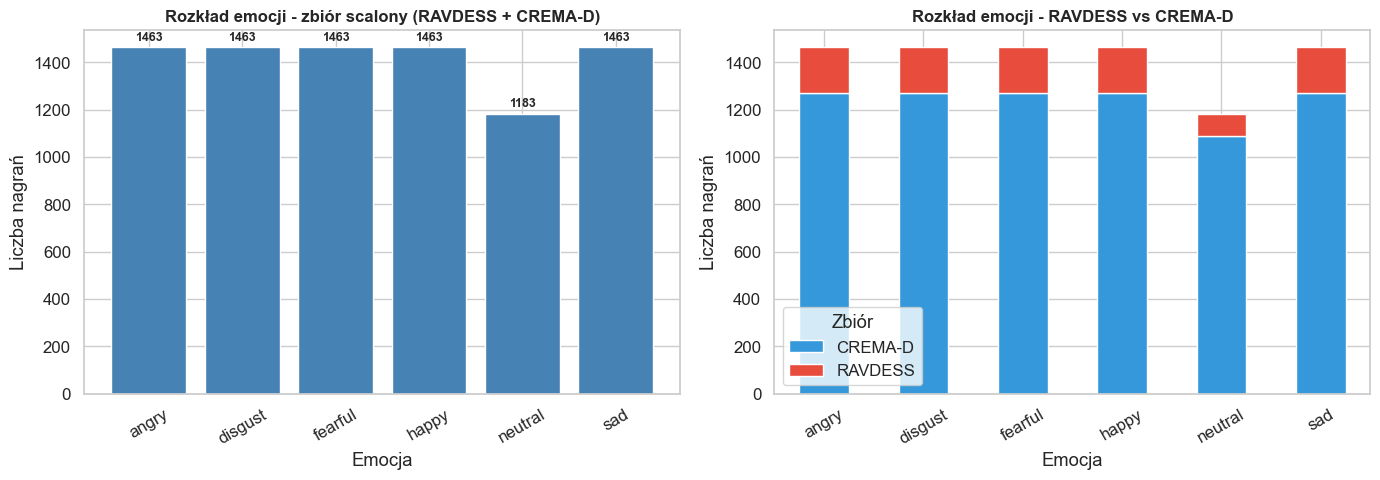

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = common_df['emotion'].value_counts().reindex(EMOTIONS_LIST)
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Rozkład emocji - zbiór scalony (RAVDESS + CREMA-D)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Emocja')
axes[0].set_ylabel('Liczba nagrań')
axes[0].tick_params(axis='x', rotation=30)

pivot = common_df.groupby(['emotion', 'dataset']).size().unstack(fill_value=0).reindex(EMOTIONS_LIST)
pivot.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='white', stacked=True)
axes[1].set_title('Rozkład emocji - RAVDESS vs CREMA-D', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Emocja')
axes[1].set_ylabel('Liczba nagrań')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Zbiór')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'merged_emotion_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Czyszczenie i normalizacja

Każde nagranie poddawane jest kolejno krokom opisanym w 1.1 oraz normalizacji amplitudy w celu zniwelowania różnic głośności między nagraniami.

In [8]:
def load_and_preprocess(filepath: str,
                        sr: int = TARGET_SR,
                        duration: float = DURATION) -> np.ndarray:
    """
    Wczytuje plik audio i przetwarza go do znormalizowanej postaci
    """
    n = int(sr * duration)

    # kroki 1 (mono) i 2 (resample)
    y, _ = librosa.load(filepath, sr=sr, mono=True)

    # krok 3 (trimming ciszy) - próg 30 dB
    # + padding (symetryczny) lub truncation (ze środka), do 3.0 sekund
    y, _ = librosa.effects.trim(y, top_db=30)

    if len(y) < n:
        pad = n - len(y)
        y = np.pad(y, (pad // 2, pad - pad // 2), mode='constant')
    else:
        start = (len(y) - n) // 2
        y = y[start : start + n]

    # krok 4 normalizacja amplitudy
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    return y.astype(np.float32)

### 3.1 Przykład wyników preprocessingu

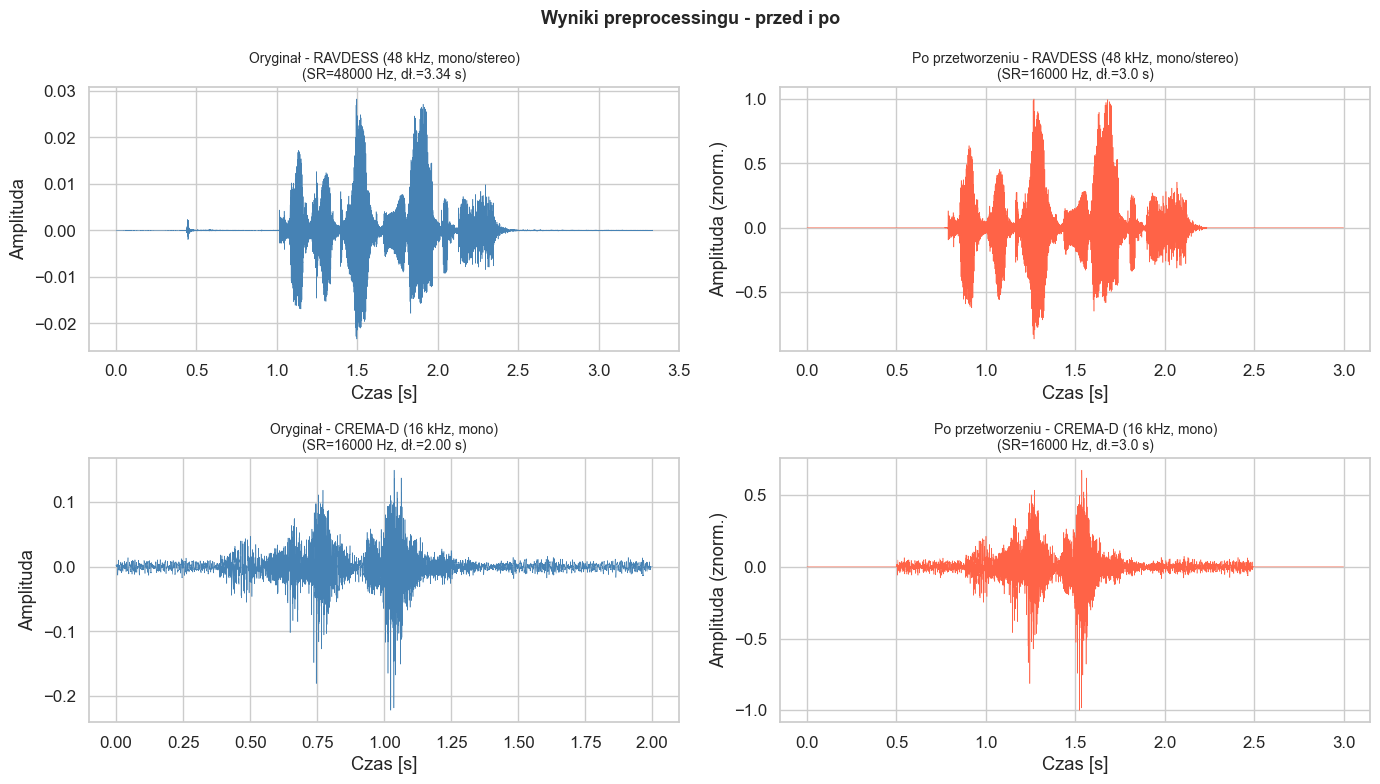

In [9]:
sample_items = {
    'RAVDESS (48 kHz, mono/stereo)': common_df[common_df['dataset'] == 'RAVDESS'].iloc[5]['filepath'],
    'CREMA-D (16 kHz, mono)': common_df[common_df['dataset'] == 'CREMA-D'].iloc[5]['filepath'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (name, path) in enumerate(sample_items.items()):
    y_orig, sr_orig = librosa.load(path, sr=None, mono=True)
    y_proc = load_and_preprocess(path)

    t_orig = np.linspace(0, len(y_orig) / sr_orig, len(y_orig))
    t_proc = np.linspace(0, DURATION, len(y_proc))

    axes[i, 0].plot(t_orig, y_orig, linewidth=0.4, color='steelblue')
    axes[i, 0].set_title(f'Oryginał - {name}\n(SR={sr_orig} Hz, dł.={len(y_orig)/sr_orig:.2f} s)', fontsize=10)
    axes[i, 0].set_xlabel('Czas [s]')
    axes[i, 0].set_ylabel('Amplituda')

    axes[i, 1].plot(t_proc, y_proc, linewidth=0.4, color='tomato')
    axes[i, 1].set_title(f'Po przetworzeniu - {name}\n(SR={TARGET_SR} Hz, dł.={DURATION} s)', fontsize=10)
    axes[i, 1].set_xlabel('Czas [s]')
    axes[i, 1].set_ylabel('Amplituda (znorm.)')

plt.suptitle('Wyniki preprocessingu - przed i po', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preprocessing_results_example.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Podział na zbiory train / validation / test

**Proporcje zbiorów:** 70% train, 15% validation, 15% test

**Podział na poziomie aktorów**  
Każdy aktor nagrał wiele różnych emocji. Jeżeli te same nagrania aktora trafią zarówno do zbioru treningowego, jak i testowego, model może nauczyć się rozpoznawać *aktora* zamiast *emocji*.  
Podział na poziomie aktorów gwarantuje, że model jest ewaluowany na mówcach, których w ogóle nie widział podczas treningu.

Stąd podział zostanie dokonany **na podstawie aktorów**, a nie losowo na poziomie próbek.

In [10]:
VALIDATE_RATIO = 0.15
TEST_RATIO = 0.15

In [11]:
def split_dataset(dataframe: pd.DataFrame,
                  val_ratio: float = VALIDATE_RATIO,
                  test_ratio: float = TEST_RATIO,
                  random_seed: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Przypisuje każdemu nagraniu etykietę {'train', 'val', 'test'}.
    Podział odbywa się na poziomie aktorów - każdy aktor należy
    wyłącznie do jednego podzbioru.

    Dla każdego datasetu (RAVDESS, CREMA-D) aktorzy są tasowani
    niezależnie, aby zachować proporcje wewnątrz każdego zbioru.
    """
    rng = np.random.default_rng(random_seed)
    result_parts = []

    for dataset in sorted(dataframe['dataset'].unique()):
        subset = dataframe[dataframe['dataset'] == dataset].copy()
        actors = np.array(sorted(subset['actor'].unique()))
        rng.shuffle(actors)

        n = len(actors)
        n_test  = max(1, round(n * test_ratio))
        n_val   = max(1, round(n * val_ratio))
        n_train = n - n_test - n_val

        test_actors  = set(actors[:n_test])
        val_actors   = set(actors[n_test : n_test + n_val])
        train_actors = set(actors[n_test + n_val:])

        subset['split'] = subset['actor'].apply(
            lambda a: 'test' if a in test_actors
                      else ('val' if a in val_actors else 'train')
        )
        result_parts.append(subset)

        print(f'{dataset}: {n} aktorów'
              f'\n\ttrain: {n_train} ({len(subset[subset["split"]=="train"])} nagrań), '
              f'\n\tval: {n_val} ({len(subset[subset["split"]=="val"])} nagrań), '
              f'\n\ttest: {n_test} ({len(subset[subset["split"]=="test"])} nagrań)\n')

    return pd.concat(result_parts, ignore_index=True)


split_df = split_dataset(common_df, val_ratio=0.15, test_ratio=0.15, random_seed=RANDOM_SEED)
print(f'\nŁączny rozkład:')
print(split_df['split'].value_counts())

CREMA-D: 91 aktorów
	train: 63 (5158 nagrań), 
	val: 14 (1142 nagrań), 
	test: 14 (1142 nagrań)

RAVDESS: 24 aktorów
	train: 16 (704 nagrań), 
	val: 4 (176 nagrań), 
	test: 4 (176 nagrań)


Łączny rozkład:
split
train    5862
val      1318
test     1318
Name: count, dtype: int64


In [12]:
print('=== Weryfikacja ===')
for ds in split_df['dataset'].unique():
    ds_df = split_df[split_df['dataset'] == ds]
    actors = {split: set(ds_df[ds_df['split'] == split]['actor']) for split in ['train', 'val', 'test']}
    assert actors['train'] & actors['val'] == set(), f'{ds}: aktor powtórzony train/val!'
    assert actors['train'] & actors['test'] == set(), f'{ds}: aktor powtórzony train/test!'
    assert actors['val'] & actors['test'] == set(), f'{ds}: aktor powtórzony val/test!'
    print(f'  {ds}: brak wycieku danych')

# Rozkład emocji w zbiorach
print('\n=== Rozkład emocji w zbiorach ===')
split_stats = split_df.groupby(['split', 'emotion']).size().unstack(fill_value=0)
print(split_stats.reindex(['train', 'val', 'test']))

=== Weryfikacja ===
  CREMA-D: brak wycieku danych
  RAVDESS: brak wycieku danych

=== Rozkład emocji w zbiorach ===
emotion  angry  disgust  fearful  happy  neutral   sad
split                                                 
train     1009     1009     1009   1009      817  1009
val        227      227      227    227      183   227
test       227      227      227    227      183   227


Rysujemy rozkład emocji na zbiorach, aby potwierdzić ich poprawność i lepiej je zobrazować.

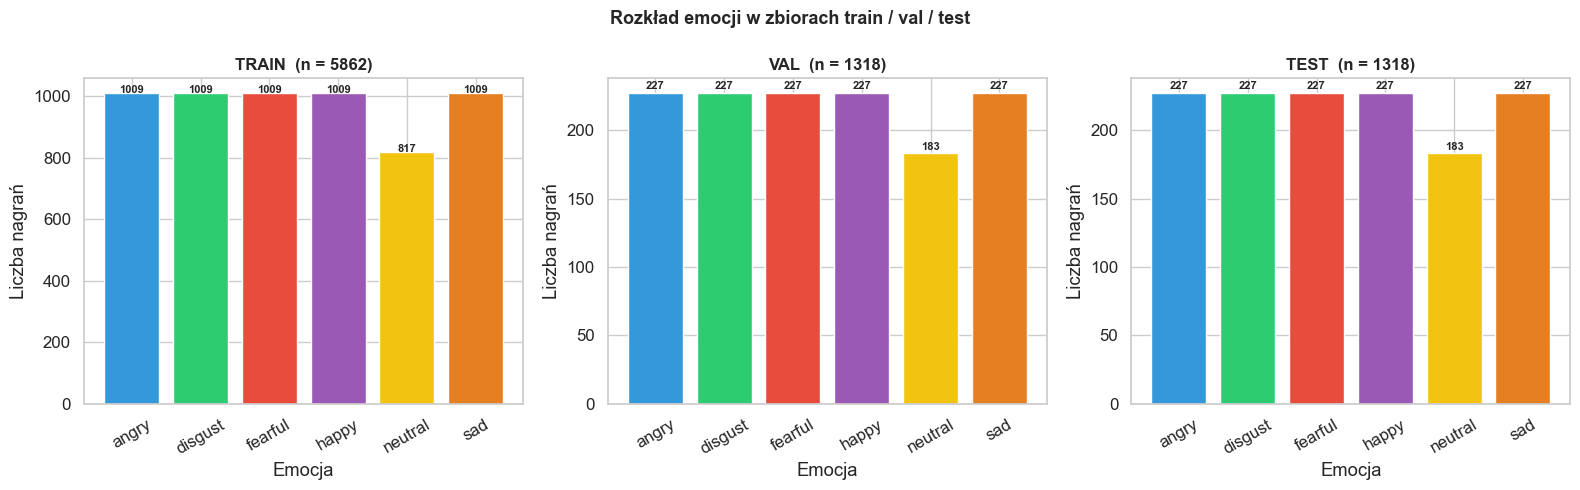

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
split_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f', '#e67e22']

for i, split in enumerate(['train', 'val', 'test']):
    subset = split_df[split_df['split'] == split]
    counts = subset['emotion'].value_counts().reindex(EMOTIONS_LIST).fillna(0)
    axes[i].bar(counts.index, counts.values, color=split_colors[:len(counts)], edgecolor='white')
    axes[i].set_title(f'{split.upper()}  (n = {len(subset)})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Emocja')
    axes[i].set_ylabel('Liczba nagrań')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 3, str(int(v)), ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Rozkład emocji w zbiorach train / val / test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'split_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

Zapisujemy metadane (ścieżka, dataset, emocja, etykieta, aktor, zbiór) do pliku.

In [14]:
split_df[['filepath', 'dataset', 'emotion', 'label', 'actor', 'split']].to_csv(
    PROCESSED_DIR / 'metadata.csv', index=False)
print('Metadane zapisane w "data/processed/metadata.csv"')

Metadane zapisane w "data/processed/metadata.csv"


## 5. Ekstrakcja cech

Modele klasyczne, CNN oraz transformerowe wymagają innego zestawu cech do działania - operują na innych danych wejściowych.  
Ze względu na powyższe przygotowujemy odpowiednie zestawy.  
1. Zestaw parametrów dla klasycznego ML
2. Mel-spektrogramy dla CNN
3. Ścieżki wav dla transformerów

### 5.1 Zestaw parametrów dla klasycznego ML

Każde nagranie opisujemy przy pomocy płaskiego wektora statystyk. Na cechy składają się:  

| Cecha | Wymiar | Uzasadnienie |
|-------|--------|------------- |
| MFCC (N=40): mean + std | 80 | Kształt spektrum - podstawowa cecha w SER |
| Δ MFCC: mean + std | 80 | Dynamika zmian spektrum |
| ΔΔ MFCC: mean + std | 80 | Przyspieszenie zmian - odzwierciedla akcent i rytm |
| ZCR: mean + std | 2 | Szorstkość głosu |
| RMS energia: mean + std | 2 | Głośność (złość/radość > smutek/neutralność) |
| Spectral centroid: mean + std | 2 | "Jasność" brzmienia |
| Spectral bandwidth: mean + std | 2 | Szerokość pasma |
| Spectral rolloff: mean + std | 2 | Granica częstotliwości 85% energii |
| Chroma STFT (12 bins): mean + std | 24 | Profil tonalny głosu |
| Spectral contrast (7 pasm): mean + std | 14 | Różnica szczyt/dolina widma - faktura dźwięku |
| **Razem** | **288** | |

Jest to wystarczający zbiór parametrów, który pokrywa kluczowe aspekty sygnału mowy: spektrum, dynamikę, energię i barwę.

In [15]:
EXPECTED_DIM = 288

def extract_features(y: np.ndarray, sr: int = TARGET_SR) -> np.ndarray:
    features = []
    # MFCC + delty (3 x 40 x 2 = 240)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    d_mfcc = librosa.feature.delta(mfcc)
    d2_mfcc = librosa.feature.delta(mfcc, order=2)
    for m in [mfcc, d_mfcc, d2_mfcc]:
        features.extend(m.mean(axis=1))
        features.extend(m.std(axis=1))
    # ZCR (2)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)
    features += [zcr.mean(), zcr.std()]
    # RMS energia (2)
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
    features += [rms.mean(), rms.std()]
    # Spectral centroid (2)
    sc = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)
    features += [sc.mean(), sc.std()]
    # Spectral bandwidth (2)
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP_LENGTH)
    features += [sb.mean(), sb.std()]
    # Spectral rolloff (2)
    sro = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)
    features += [sro.mean(), sro.std()]
    # Chroma STFT (12 x 2 = 24)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    features.extend(chroma.mean(axis=1))
    features.extend(chroma.std(axis=1))
    # Spectral contrast (7 x 2 = 14)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    features.extend(contrast.mean(axis=1))
    features.extend(contrast.std(axis=1))
    return np.array(features, dtype=np.float32)

# Sprawdzenie wymiaru dla jednego przykładu
y_test_sample = load_and_preprocess(split_df.iloc[0]['filepath'])
feat_test = extract_features(y_test_sample)
assert feat_test.shape[0] == EXPECTED_DIM, f'Niepoprawny rozmiar ({feat_test.shape[0]} != {EXPECTED_DIM}) wektora cech {feat_test.shape}!'
print(f'Wektor cech ML: {feat_test.shape} ({feat_test.shape[0]} cech)')

Wektor cech ML: (288,) (288 cech)


### 5.2 Mel-spektrogramy dla CNN

Spektogram melowy pokazuje częstotliwości sygnału w czasie jednak w porównaniu do zwykłego spektogramu lepiej odwzorowuje percepcje ludzkiego ucha - logarytmiczną wrażliwość.  
W porównaniu do surowego sygnału waveform, mel-spektrogram znacząco zmniejsza ilość danych w sygnale wejściowym i ułatwia ekstrakcję istotnych cech.
Ze względu na powyższe jest on optymalnym wyborem jako wejście sieci CNN.

In [16]:
def mel_spectrogram(y: np.ndarray, sr: int = TARGET_SR) -> np.ndarray:
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)

# Sprawdzenie wymiaru dla jednego przykładu
y_test_sample = load_and_preprocess(split_df.iloc[0]['filepath'])
mel_test = mel_spectrogram(y_test_sample)
print(f'Mel-spektrogram CNN:  {mel_test.shape}   ({mel_test.shape[0]} mel x {mel_test.shape[1]} klatek)')

Mel-spektrogram CNN:  (128, 94)   (128 mel x 94 klatek)


### 5.3 Cechy dla architektury transformerów

Wybrany model transofmerowy to HuBERT.

HuBERT to model wav2vec - oznacza to, że danymi wejściowymi jest waveform, ze względu na to nie potrzebna jest żadna dodatkowa ekstrakcja cech.  



### 5.4 Ekstrakcja cech

W tym kroku korzystamy z wyżej zdefiniowanych funkcji do ekstrakcji cech.  
**Może to zająć kilka minut**

In [17]:
all_features = []  # wektory cech dla ML
all_mels = []      # mel-spektrogramy dla CNN
all_labels = []    # etykiety numeryczne
all_splits = []    # przynależność do podzbioru
error_indices = []

for idx, row in tqdm(split_df.iterrows(), total=len(split_df), desc='Ekstrakcja cech'):
    try:
        y = load_and_preprocess(row['filepath'])
        all_features.append(extract_features(y))
        all_mels.append(mel_spectrogram(y))
        all_labels.append(row['label'])
        all_splits.append(row['split'])
    except Exception as e:
        error_indices.append((idx, str(e)))

if error_indices:
    print(f'\nBłędy ({len(error_indices)}): {error_indices[:3]}')
else:
    print(f'\nEkstrakcja zakończona bez błędów.')

all_features = np.array(all_features)
all_mels = np.array(all_mels)
all_labels = np.array(all_labels)
all_splits = np.array(all_splits)

print(f'\nall_features: {all_features.shape}')
print(f'all_mels:     {all_mels.shape}')
print(f'all_labels:   {all_labels.shape}')

Ekstrakcja cech: 100%|██████████| 8498/8498 [03:17<00:00, 43.05it/s]



Ekstrakcja zakończona bez błędów.

all_features: (8498, 288)
all_mels:     (8498, 128, 94)
all_labels:   (8498,)


### 5.5 Przypisanie wyekstrahowanych cech do zbiorów train/val/test

SVM i podobne modele są wrażliwe na skalę wartości cech i bez normalizacji największe liczbowo wartości zdominują wszystko, mimo że nie są ważniejsze od reszty.

Skalowanie odbędzie się jednak na etapie trenowania modelu (w Pipeline), tak aby uniknąć wycieku informacji do CV (wytłumaczenie w notebook'u 3_Models_Training).  

Dla spektogramów melowych normalizacji możemy dokonać apriori, ponieważ każdy spektogram jest rozpatrywany osobno, bez zależności do innych, co oznacza brak wycieku informacji.

In [18]:
def get_split_mask(splits_arr, name):
    return splits_arr == name

for split in ['train', 'val', 'test']:
    mask = get_split_mask(all_splits, split)
    globals()[f'X_ml_{split}'] = all_features[mask]
    globals()[f'X_mel_{split}'] = all_mels[mask]
    globals()[f'y_{split}'] = all_labels[mask]

# Normalizacja mel-spektrogramów - per spektrogram min-max do [-1, 1]
def normalize_mel(mel_array: np.ndarray) -> np.ndarray:
    """Per-sample normalizacja mel-spektrogramów do zakresu [-1, 1]."""
    out = np.empty_like(mel_array)
    for i, m in enumerate(mel_array):
        min_v, max_v = m.min(), m.max()
        rng = max_v - min_v
        out[i] = 2.0 * (m - min_v) / rng - 1.0 if rng > 0 else np.zeros_like(m)
    return out

X_mel_train = normalize_mel(X_mel_train)
X_mel_val = normalize_mel(X_mel_val)
X_mel_test = normalize_mel(X_mel_test)

print('Rozmiary po podziale i normalizacji:')
for split in ['train', 'val', 'test']:
    ml = globals()[f'X_ml_{split}']
    mel = globals()[f'X_mel_{split}']
    y = globals()[f'y_{split}']
    print(f'  {split:5s}: ML={ml.shape}, Mel={mel.shape}, y={y.shape}')

Rozmiary po podziale i normalizacji:
  train: ML=(5862, 288), Mel=(5862, 128, 94), y=(5862,)
  val  : ML=(1318, 288), Mel=(1318, 128, 94), y=(1318,)
  test : ML=(1318, 288), Mel=(1318, 128, 94), y=(1318,)


## 6. Augmentacja zbioru treningowego

Augmentacja jest stosowana **wyłącznie na zbiorze treningowym**.
Przed jej zastosowaniem wykonano podział, aby augmentowane próbki nie trafiły do val/test.

Celem augmentacji jest **zwiększenie liczby przykładów treningowych** oraz **regularyzacja** (sztuczne zniekształcenia zmuszają model do uczenia się cech niezmiennych na transformacje) dla sieci głębokich - operujących na spektrogramach 2D i transformerach.  
Dla SVM z wektorem 250 statystyk (mean/std MFCC po 3 sekundach) augmentowane próbki nie wnoszą nowej informacji, a znacząco zwiększają rozmiar problemu i czas treningu, dlatego pominięto augmentację. 

### Zastosowane techniki

1. Szum gaussowski (σ = 0.005) - Symuluje szumy tła i nagrania
2. Time-stretching (rate = 0.85) - Wolniejsza wymowa
3. Time-stretching (rate = 1.15) - Szybsza wymowa
4. Pitch-shifting (-2 półtony) - Zmiana barwy głosu na niższą
5. Pitch-shifting (+2 półtony) - Zmiana barwy głosu na wyższą

In [19]:
AUG_METHODS = ['noise', 'stretch_slow', 'stretch_fast', 'pitch_down', 'pitch_up']

def _fix_length(y: np.ndarray) -> np.ndarray:
    """Powrót długości próbki do 3s po augmentacji + peak-normalizacja."""
    n = N_SAMPLES
    if len(y) < n:
        pad = n - len(y)
        y = np.pad(y, (pad // 2, pad - pad // 2), mode='constant')
    else:
        start = (len(y) - n) // 2
        y = y[start : start + n]
    max_val = np.max(np.abs(y))
    return (y / max_val).astype(np.float32) if max_val > 0 else y


def augment(y: np.ndarray, method: str, sr: int = TARGET_SR) -> np.ndarray:
    """Stosuje wybraną metodę augmentacji."""
    if method == 'noise':
        y_aug = y + np.random.normal(0, NOISE_FACTOR, y.shape).astype(np.float32)
    elif method == 'stretch_slow':
        y_aug = librosa.effects.time_stretch(y, rate=STRETCH_RATES[0])
    elif method == 'stretch_fast':
        y_aug = librosa.effects.time_stretch(y, rate=STRETCH_RATES[1])
    elif method == 'pitch_down':
        y_aug = librosa.effects.pitch_shift(y, sr=sr, n_steps=PITCH_STEPS[0])
    elif method == 'pitch_up':
        y_aug = librosa.effects.pitch_shift(y, sr=sr, n_steps=PITCH_STEPS[1])
    else:
        raise ValueError(f'Nieznana metoda: {method}')
    return _fix_length(y_aug)

Każdy przykład treningowy zostaje zaugmentowany losowo przez 1-2 techniki zdefiniowane powyżej.  
Stosowanie losowej liczby augmentacji na próbkę ma zapobiec generowaniu nienaturalnych sygnałów oraz zwiększyć różnorodność danych treningowych.  
Dzięki temu, generalizacja modelu powinna ulec poprawie, a ryzyko overfittingu zostać zmniejszone.

In [20]:
import soundfile as sf

AUGMENTED_DIR = PROCESSED_DIR / 'augmented'
AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

N_AUG_PER_SAMPLE = np.random.randint(1, 3)

aug_labels_list = []
aug_mels_list = []
aug_meta_rows = []

train_mask_df = split_df['split'] == 'train'
train_df = split_df[train_mask_df].reset_index(drop=True)

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc='Augmentacja'):
    emotion = row['emotion']
    label_val = label_encoder.transform([emotion])[0]
    orig_stem = Path(row['filepath']).stem
    try:
        y_orig = load_and_preprocess(row['filepath'])
        for aug_i in range(N_AUG_PER_SAMPLE):
            method = np.random.choice(AUG_METHODS)
            y_aug  = augment(y_orig, method)

            # zapis waveform'u
            aug_filename = f'{orig_stem}_{method}.wav'
            aug_path = AUGMENTED_DIR / aug_filename
            sf.write(str(aug_path), y_aug, TARGET_SR)

            aug_mels_list.append(mel_spectrogram(y_aug))
            aug_labels_list.append(label_val)
            aug_meta_rows.append({
                'filepath':   str(aug_path),
                'dataset':    row['dataset'],
                'emotion':    emotion,
                'label':      label_val,
                'actor':      row['actor'],
                'split':      'aug',
                'aug_method': method,
            })
    except Exception:
        pass

# Dołączenie próbek augmentowanych do zbioru treningowego
if aug_labels_list:
    y_aug = np.array(aug_labels_list)
    y_train_aug = np.concatenate([y_train, y_aug])
    X_mel_aug = normalize_mel(np.array(aug_mels_list))
    X_mel_train = np.vstack([X_mel_train, X_mel_aug])

print(f'\nZbiór treningowy po augmentacji y_train: {len(y_train_aug)} próbek')
print(f'Zbiór treningowy po augmentacji X_mel_train: {len(X_mel_train)} próbek')
after_dist = pd.Series(label_encoder.inverse_transform(y_train_aug)).value_counts().to_dict()
print(f'Rozkład klas po augmentacji: {after_dist}')
print(f'\nZapisano {len(aug_meta_rows)} plików augmentowanych w {AUGMENTED_DIR}')

Augmentacja: 100%|██████████| 5862/5862 [01:28<00:00, 66.22it/s]



Zbiór treningowy po augmentacji y_train: 11724 próbek
Zbiór treningowy po augmentacji X_mel_train: 11724 próbek
Rozkład klas po augmentacji: {'angry': 2018, 'disgust': 2018, 'fearful': 2018, 'happy': 2018, 'sad': 2018, 'neutral': 1634}

Zapisano 5862 plików augmentowanych w d:\zum\data\processed\augmented


Rozkład klas w zbiorze treningowym przed i po augmentacji.

In [21]:
# Dołączenie wierszy augmentowanych do metadata.csv
meta_path = PROCESSED_DIR / 'metadata.csv'
base_meta_df = pd.read_csv(meta_path)

aug_meta_df = pd.DataFrame(aug_meta_rows)
combined_meta = pd.concat([base_meta_df, aug_meta_df], ignore_index=True)
combined_meta.to_csv(meta_path, index=False)

print(f'metadata.csv zaktualizowane:')
print(f'  oryginalne wiersze: {len(base_meta_df)}')
print(f'  wiersze aug:        {len(aug_meta_df)}')
print(f'  łącznie:            {len(combined_meta)}')
print(f'\nRozkład kolumny split:')
print(combined_meta["split"].value_counts())

metadata.csv zaktualizowane:
  oryginalne wiersze: 8498
  wiersze aug:        5862
  łącznie:            14360

Rozkład kolumny split:
split
train    5862
aug      5862
val      1318
test     1318
Name: count, dtype: int64


In [22]:
before  = split_df[train_mask_df]['emotion'].value_counts().reindex(EMOTIONS_LIST)
after = (
    pd.Series(label_encoder.inverse_transform(y_train_aug))
    .value_counts()
    .reindex(EMOTIONS_LIST)
)
comparison = pd.DataFrame({
    'before': before,
    'after': after
})
print(comparison)

         before  after
angry      1009   2018
disgust    1009   2018
fearful    1009   2018
happy      1009   2018
neutral     817   1634
sad        1009   2018


## 7. Zapis przetworzonych danych

Wszystkie artefakty są zapisywane do katalogu **data/processed/**. Struktura:

```
data/processed/
    X_ml_train.npy   # cechy ML (train, bez augmentacji)
    X_ml_val.npy
    X_ml_test.npy
    X_mel_train.npy  # mel-spektrogramy CNN (train, po augmentacji)
    X_mel_val.npy
    X_mel_test.npy
    y_train.npy      # etykiety numeryczne próbki treningowe bez augmentacji
    y_train_aug.npy  # etykiety numeryczne próbki treningowe wraz z augmentacją
    y_val.npy
    y_test.npy
    label_encoder.pkl
    metadata.csv     # metadane z podziałem
```

In [23]:
SET_PARAMS = [
    ('X_ml_train', X_ml_train),
    ('X_ml_val', X_ml_val),
    ('X_ml_test', X_ml_test),
    ('X_mel_train', X_mel_train),
    ('X_mel_val', X_mel_val),
    ('X_mel_test', X_mel_test),
    ('y_train', y_train),
    ('y_train_aug', y_train_aug),
    ('y_val', y_val),
    ('y_test', y_test)
]

for name, arr in SET_PARAMS:
    path = PROCESSED_DIR / f'{name}.npy'
    np.save(path, arr)
    print(f"Zapisano {path.name:<16} {str(arr.shape):<20} dtype={str(arr.dtype):<8}")

with open(PROCESSED_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print('\nLabelEncoder zapisany.')

Zapisano X_ml_train.npy   (5862, 288)          dtype=float32 
Zapisano X_ml_val.npy     (1318, 288)          dtype=float32 
Zapisano X_ml_test.npy    (1318, 288)          dtype=float32 
Zapisano X_mel_train.npy  (11724, 128, 94)     dtype=float32 
Zapisano X_mel_val.npy    (1318, 128, 94)      dtype=float32 
Zapisano X_mel_test.npy   (1318, 128, 94)      dtype=float32 
Zapisano y_train.npy      (5862,)              dtype=int64   
Zapisano y_train_aug.npy  (11724,)             dtype=int64   
Zapisano y_val.npy        (1318,)              dtype=int64   
Zapisano y_test.npy       (1318,)              dtype=int64   

LabelEncoder zapisany.


In [25]:
# Podsumowanie końcowe
print('=' * 55)
print('        PODSUMOWANIE PRZETWARZANIA')
print('=' * 55)
print(f'Zbiór scalony:   {len(split_df)} nagrań, {len(EMOTIONS_LIST)} klas emocji')
print(f'Sample rate:     {TARGET_SR} Hz  |  Długość: {DURATION} s')
print()
print(f'Cechy ML:        {X_ml_train.shape[1]} cech/próbkę')
print(f'Mel-spektrogram: {X_mel_train.shape[1]}x{X_mel_train.shape[2]} ({N_MELS} mel x T klatek)')
print()
print(f'{"Zbiór":<8} {"ML":>12} {"Mel":>20} {"Ścieżki":>12}')
print('-' * 55)
for split in ['train', 'val', 'test']:
    ml  = globals()[f'X_ml_{split}']
    mel = globals()[f'X_mel_{split}']
    wavs = len(split_df[split_df["split"] == split])
    if split == "train":
        wavs += len(aug_meta_df)
    print(f'{split:<8} {str(ml.shape):>12} {str(mel.shape):>20} {str(wavs):>12}')
print()
print(f'{"Etykiety":<14} {"Wymiar":>40}')
print('-' * 55)
for name in ['train', 'train_aug', 'val', 'test']:
    y = globals()[f'y_{name}']
    print(f'{name:<14} {str(y.shape[0]):>40}')

print('=' * 55)
print(f'Klasy: {list(label_encoder.classes_)}')
print()
print(f'Augmentacja (split=aug):')
print(f'  Pliki wav:  {len(aug_meta_rows)} w data/processed/augmented/')
aug_method_counts = pd.Series([r["aug_method"] for r in aug_meta_rows]).value_counts()
for method, count in aug_method_counts.items():
    print(f'    {method:<14} {count}')
print(f'\nDane gotowe do treningu')

        PODSUMOWANIE PRZETWARZANIA
Zbiór scalony:   8498 nagrań, 6 klas emocji
Sample rate:     16000 Hz  |  Długość: 3.0 s

Cechy ML:        288 cech/próbkę
Mel-spektrogram: 128x94 (128 mel x T klatek)

Zbiór              ML                  Mel      Ścieżki
-------------------------------------------------------
train     (5862, 288)     (11724, 128, 94)        11724
val       (1318, 288)      (1318, 128, 94)         1318
test      (1318, 288)      (1318, 128, 94)         1318

Etykiety                                         Wymiar
-------------------------------------------------------
train                                              5862
train_aug                                         11724
val                                                1318
test                                               1318
Klasy: [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]

Augmentacja (split=aug):
  Pliki wav:  5862 w data/process